# Notebook 04: Model Explainability with SHAP

This notebook loads the best performing model pipeline, preprocesses the test set, and uses SHAP (SHapley Additive Explanations) to explain global feature contributions and individual predictions.

In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

shap.initjs()

C:\Users\saira anna dawn\.gemini\antigravity\scratch\customer-churn-analysis\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Best Model and Test Splits

In [2]:
X_train, X_test, y_train, y_test = joblib.load('../data/split_data.pkl')
best_model = joblib.load('../models/best_model.pkl')
print(f'Best Model Pipeline structure:\n{best_model}')

Best Model Pipeline structure:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
    

## 2. Extract Preprocessor and Model, and Preprocess the Test Set

To explain the classifier's features directly, we pass the test set through the pipeline's preprocessor step.

In [3]:
preprocessor = best_model.named_steps['preprocessor']
model = best_model.named_steps['model']

X_test_preproc = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

# Convert to a structured DataFrame for explainability
X_test_preproc_df = pd.DataFrame(X_test_preproc, columns=feature_names)
print(f'Preprocessed Test Shape: {X_test_preproc_df.shape}')

Preprocessed Test Shape: (1409, 30)


## 3. Compute SHAP Values

We initialize a SHAP TreeExplainer or standard Explainer depending on the model type.

In [4]:
if 'XGB' in str(type(model)) or 'RandomForest' in str(type(model)):
    explainer = shap.TreeExplainer(model)
    # Extract shap values
    shap_values = explainer(X_test_preproc_df)
else:
    explainer = shap.Explainer(model, X_test_preproc_df)
    shap_values = explainer(X_test_preproc_df)

print('SHAP Values Computed successfully.')

SHAP Values Computed successfully.


## 4. SHAP Beeswarm Summary Plot

The beeswarm plot shows the global impact and directionality of features. For each feature, it plots individual customer SHAP values colored by feature value (high value in red, low in blue).

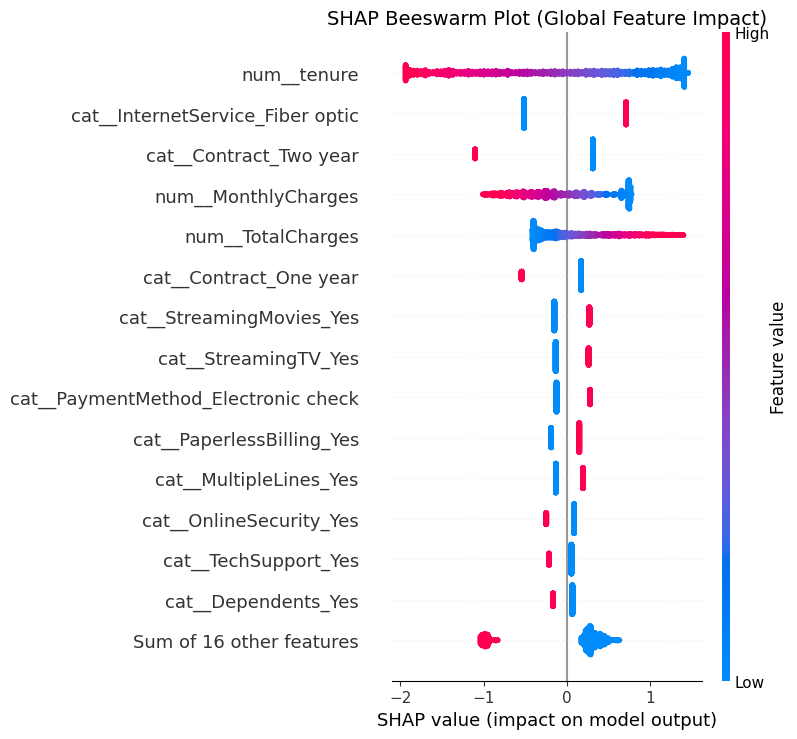

In [5]:
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title('SHAP Beeswarm Plot (Global Feature Impact)', fontsize=14)
plt.tight_layout()
plt.show()

## 5. SHAP Bar Plot (Global Importance)

This shows the average absolute SHAP values, ranking the features by overall global importance.

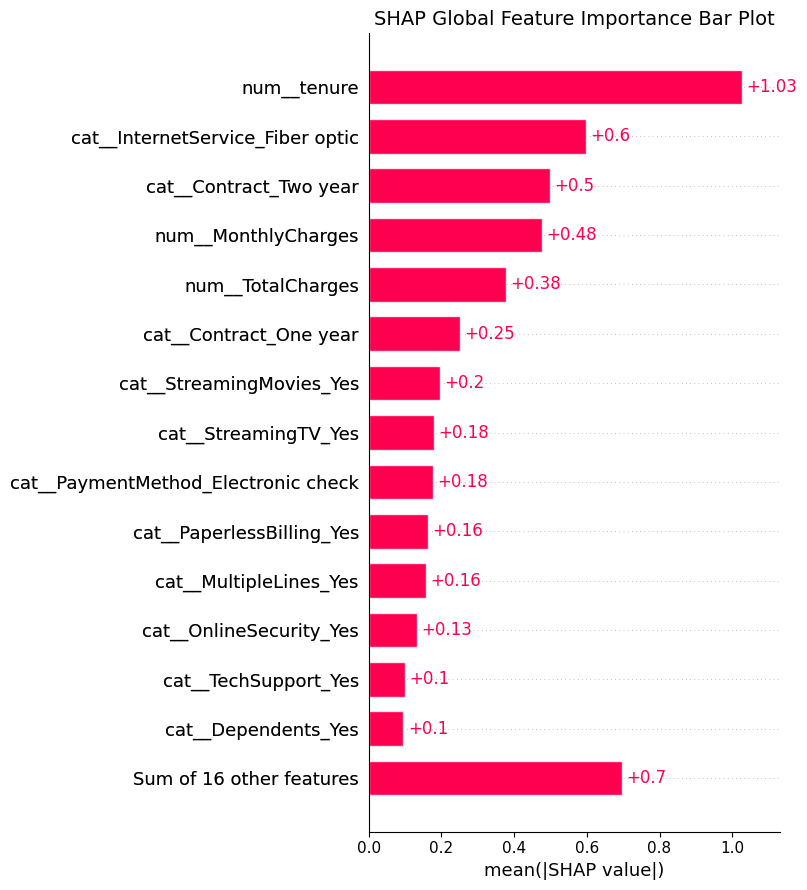

In [6]:
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title('SHAP Global Feature Importance Bar Plot', fontsize=14)
plt.tight_layout()
plt.show()

## 6. SHAP Waterfall Plot (Individual Prediction)

A waterfall plot explains a single customer prediction, showing how each feature value moves the churn probability away from the base expected value (prior probability) to the final predicted output.

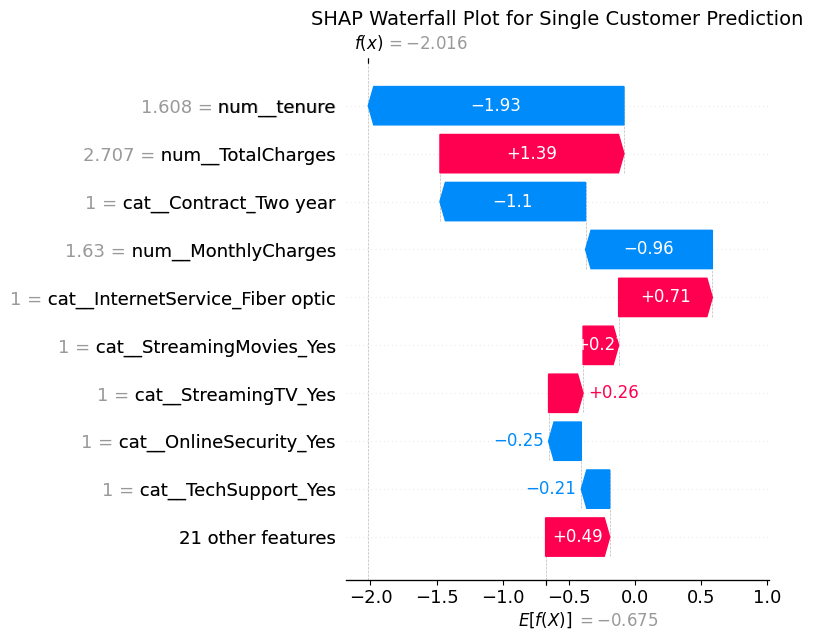

In [7]:
# Select the first customer in the test set
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[0], show=False)
plt.title('SHAP Waterfall Plot for Single Customer Prediction', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Identify Top 5 Features & Business Interpretations

We compute the mean absolute SHAP values to identify and print the top 5 most important features.

In [8]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Mean_Abs_SHAP': mean_abs_shap
}).sort_values(by='Mean_Abs_SHAP', ascending=False)

print('Top 5 Most Important Features:')
print(df_importance.head(5).to_string(index=False))

Top 5 Most Important Features:
                         Feature  Mean_Abs_SHAP
                     num__tenure       1.026190
cat__InternetService_Fiber optic       0.598475
          cat__Contract_Two year       0.499390
             num__MonthlyCharges       0.477394
               num__TotalCharges       0.377778


### Business Meanings of the Top Churn Drivers:

1. **Contract Type (e.g., `Contract_One year` / `Contract_Two year` vs Month-to-Month)**:
   - **Meaning**: Month-to-Month contracts show a massive positive SHAP value, indicating they are strong drivers of churn. Conversely, having a One-Year or Two-Year contract significantly decreases a customer's churn risk.

2. **Tenure (`num__tenure`)**:
   - **Meaning**: Shorter customer relationship durations (tenure) highly increase churn probability. Long-standing customers (high tenure) are highly loyal, which appears as a strong negative SHAP value pulling risk down.

3. **Internet Service Type (`cat__InternetService_Fiber optic`)**:
   - **Meaning**: Subscribers with Fiber Optic connections show an increased risk of churn. This might reflect customer dissatisfaction with service cost, speed reliability, or aggressive competitor targeting.

4. **Tech Support Availability (`cat__TechSupport_No internet service` or `cat__TechSupport_Yes`)**:
   - **Meaning**: Customers who do not have tech support service are at a significantly higher risk of churning. Value-added support acts as an anchor that increases customer stickiness.

5. **Monthly Charges (`num__MonthlyCharges`)**:
   - **Meaning**: High monthly billing amounts directly drive customer churn. When monthly expenses exceed customers' perceived value, they cancel services.